# **Day 5: Data Visualisation with Matplotlib and Seaborn**
*Module 1 - Foundations and Tools*

A good figure finds bugs, reveals patterns and convinces reviewers. Today we learn the **object-oriented Matplotlib API** (full control, publication quality) and **Seaborn** (fast statistical plots).

> A good plot shows patterns that numbers hide. Histograms show distributions, scatter plots show relationships, box plots compare groups. Choose the plot for the question we want to answer.
>
> *Example:* Two crops may have the same average NDVI, but a histogram shows that one is spread widely (mixed fields) while the other is tight (uniform fields), which matters for classification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(5)
from sklearn.datasets import load_wine     # bundled with scikit-learn: no download needed
wine = load_wine(as_frame=True)
df = wine.frame.rename(columns={"target": "cultivar"})
df["cultivar"] = df.cultivar.map({0: "A", 1: "B", 2: "C"})
df.iloc[:3, :6]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols
0,14.23,1.71,2.43,15.6,127.0,2.80
1,13.20,1.78,2.14,11.2,100.0,2.65
2,13.16,2.36,2.67,18.6,101.0,2.80


## **1. Figure and Axes**
`fig` is the whole canvas; each `ax` is one panel. Always call methods on `ax`; it scales to multi-panel figures.

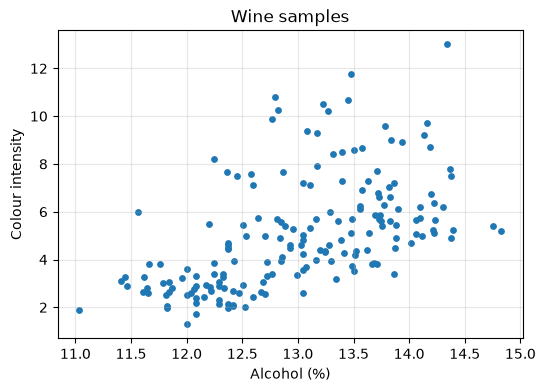

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df.alcohol, df.color_intensity, s=15)
ax.set_xlabel("Alcohol (%)")
ax.set_ylabel("Colour intensity")
ax.set_title("Wine samples")
ax.grid(alpha=0.3)
plt.show()

## **2. The Essential Plots for ML**

| Question | Plot |
|---|---|
| How is one variable distributed? | Histogram, KDE, box plot |
| How are two variables related? | Scatter, hexbin, regression line |
| How does a feature differ between classes? | Box / violin / strip plot with `hue` |
| How do variables correlate? | Correlation heatmap |
| How does something change over time / training? | Line plot |
| What does an image or map look like? | `imshow` with a colour bar |

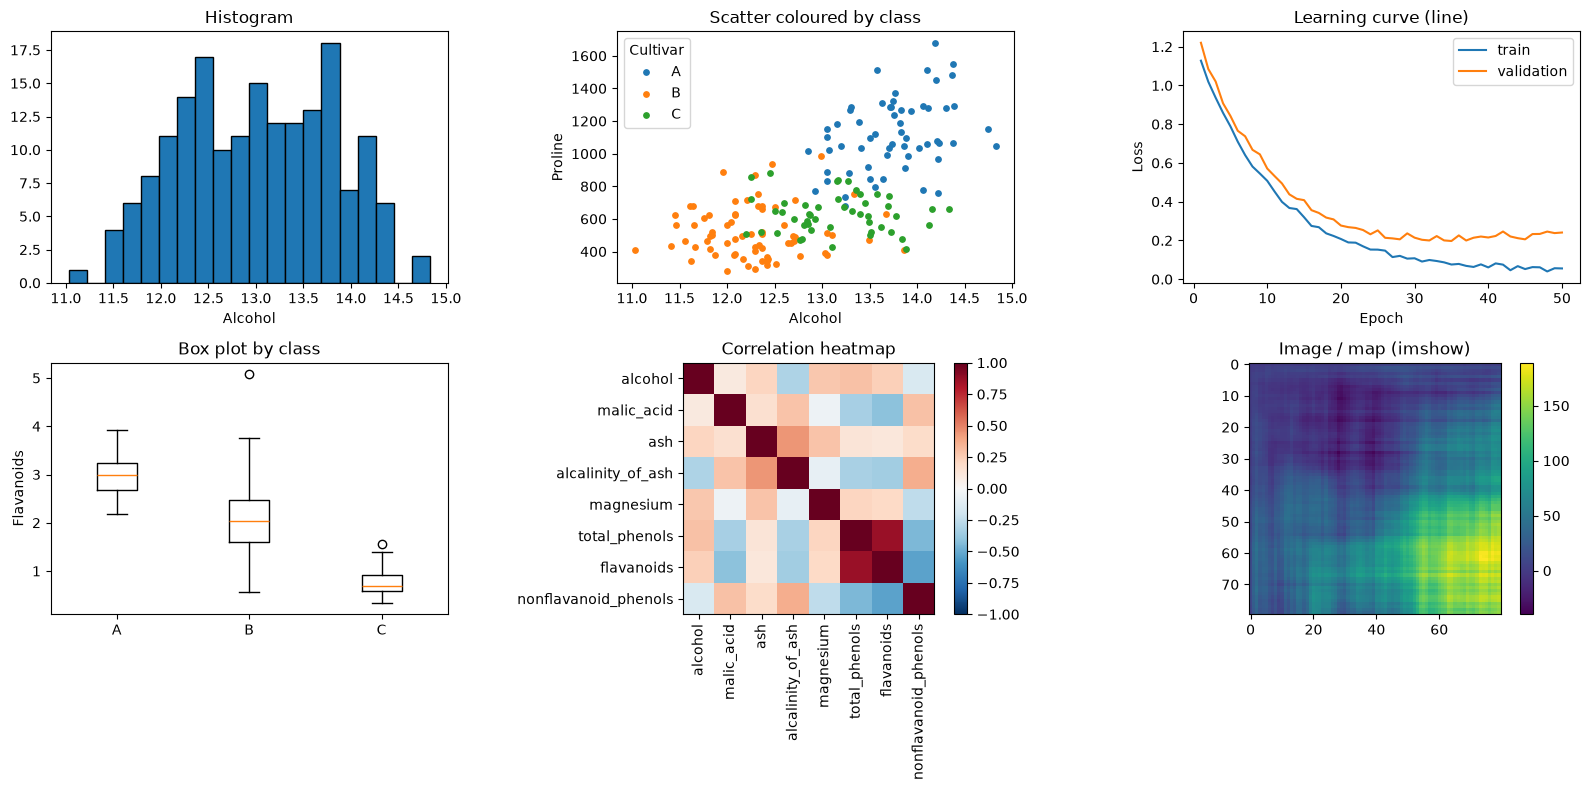

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(df.alcohol, bins=20, edgecolor="k")
axes[0, 0].set(title="Histogram", xlabel="Alcohol")

for c, g in df.groupby("cultivar"):
    axes[0, 1].scatter(g.alcohol, g.proline, s=15, label=c)
axes[0, 1].set(title="Scatter coloured by class", xlabel="Alcohol", ylabel="Proline"); axes[0, 1].legend(title="Cultivar")

epochs = np.arange(1, 51)
train_loss = 1.2 * np.exp(-epochs / 10) + 0.05 + rng.normal(0, 0.01, 50)
val_loss = 1.2 * np.exp(-epochs / 10) + 0.12 + 0.004 * np.maximum(0, epochs - 20) + rng.normal(0, 0.015, 50)
axes[0, 2].plot(epochs, train_loss, label="train"); axes[0, 2].plot(epochs, val_loss, label="validation")
axes[0, 2].set(title="Learning curve (line)", xlabel="Epoch", ylabel="Loss"); axes[0, 2].legend()

axes[1, 0].boxplot([g.flavanoids for _, g in df.groupby("cultivar")], tick_labels=["A", "B", "C"])
axes[1, 0].set(title="Box plot by class", ylabel="Flavanoids")

corr = df.drop(columns="cultivar").iloc[:, :8].corr()
im = axes[1, 1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(8), corr.columns, rotation=90); axes[1, 1].set_yticks(range(8), corr.columns)
axes[1, 1].set_title("Correlation heatmap"); fig.colorbar(im, ax=axes[1, 1])

field = np.cumsum(np.cumsum(rng.normal(size=(80, 80)), 0), 1)
im2 = axes[1, 2].imshow(field, cmap="viridis"); axes[1, 2].set_title("Image / map (imshow)")
fig.colorbar(im2, ax=axes[1, 2])
plt.tight_layout(); plt.show()

The learning curve already tells a story: validation loss starts rising after ~20 epochs while training loss keeps falling. That is **overfitting** (Day 16).

## **3. Seaborn: Statistical Plots in One Line**

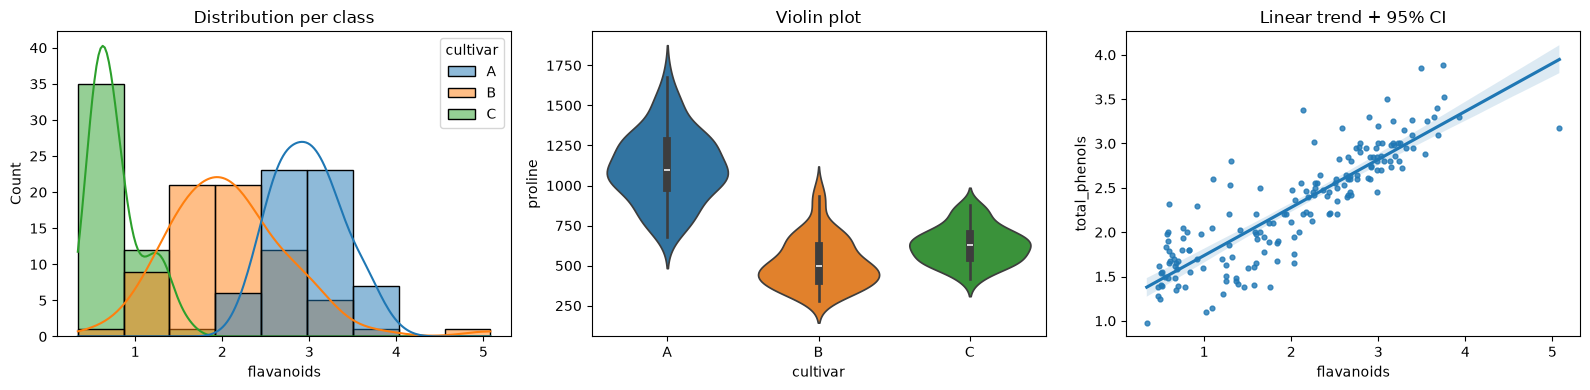

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=df, x="flavanoids", hue="cultivar", kde=True, ax=axes[0])
sns.violinplot(data=df, x="cultivar", y="proline", hue="cultivar", ax=axes[1], legend=False)
sns.regplot(data=df, x="flavanoids", y="total_phenols", ax=axes[2], scatter_kws={"s": 12})
axes[0].set_title("Distribution per class"); axes[1].set_title("Violin plot"); axes[2].set_title("Linear trend + 95% CI")
plt.tight_layout(); plt.show()

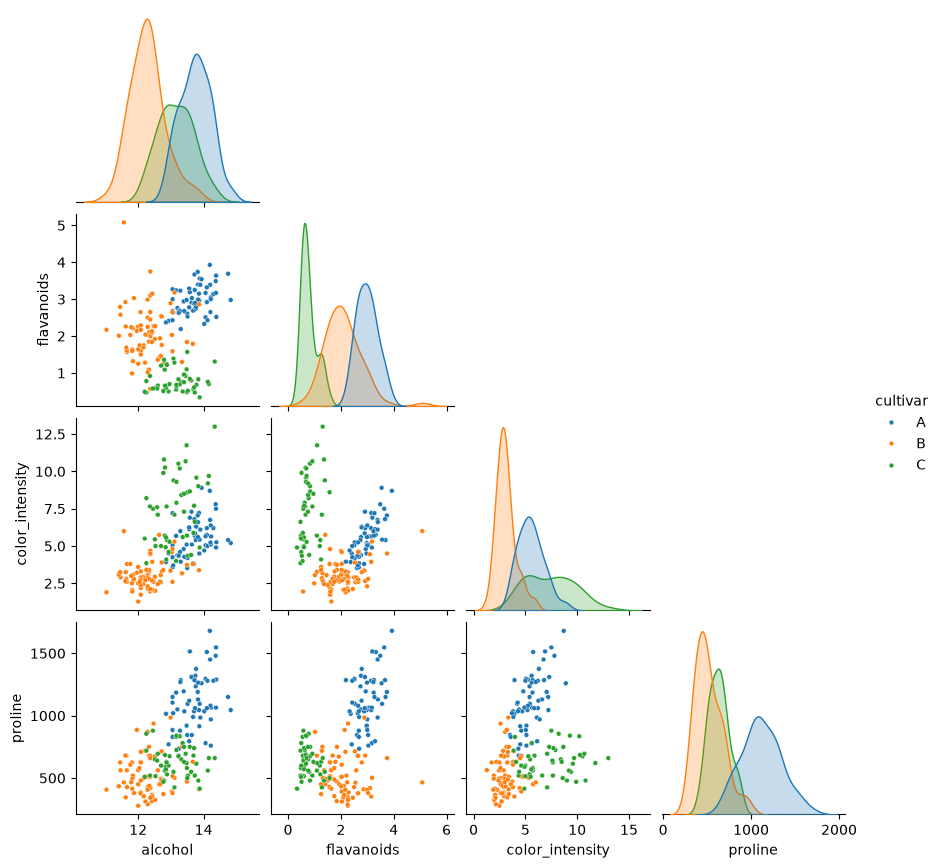

In [5]:
sns.pairplot(df[["alcohol", "flavanoids", "color_intensity", "proline", "cultivar"]], hue="cultivar",
             corner=True, plot_kws={"s": 12}, height=2.2)
plt.show()

The pair plot shows immediately that `flavanoids` and `proline` separate the cultivars well. Visual EDA often tells us which features matter **before** any model is trained.

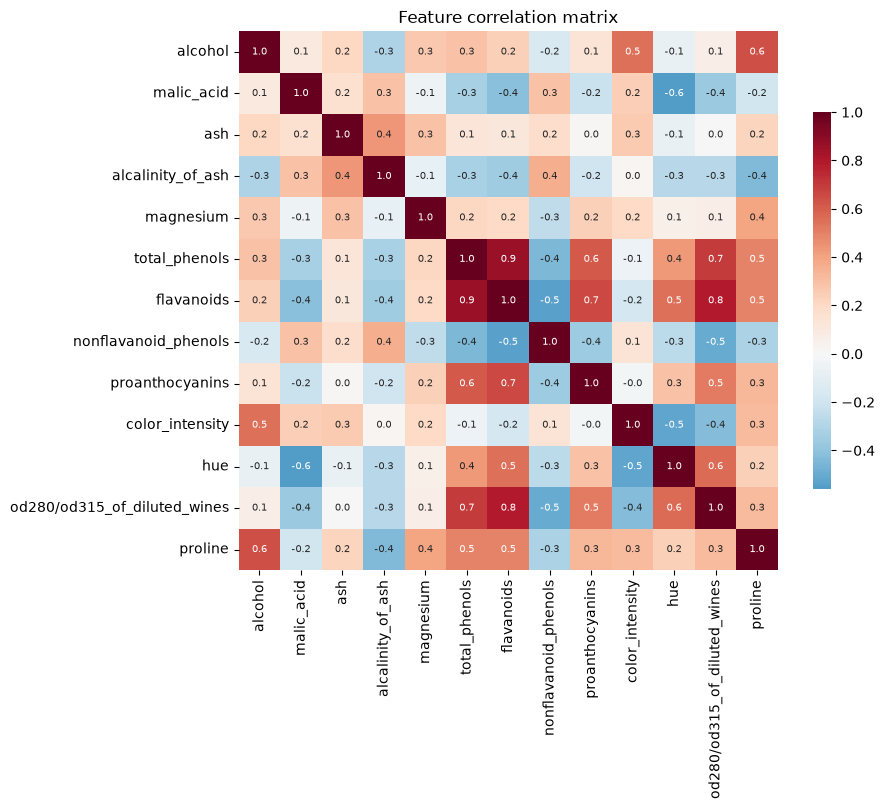

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.drop(columns="cultivar").corr(), cmap="RdBu_r", center=0, annot=True, fmt=".1f",
            annot_kws={"size": 7}, square=True, cbar_kws={"shrink": 0.7})
plt.title("Feature correlation matrix"); plt.show()

# **Part 2: Publication-Quality Figures**

Journals require: readable fonts at final size (usually 8-10 pt), vector format (PDF/SVG/EPS) or >= 300 dpi raster, colour-blind-safe colours, panel labels (a), (b), (c), units on every axis.

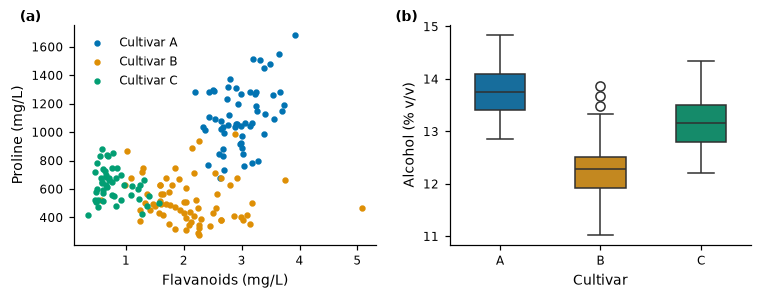

In [7]:
def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9, "axes.titlesize": 10,
        "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
        "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans",
    })

set_pub_style()
cb = sns.color_palette("colorblind")
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))       # 7 inch = full page width of most journals
for i, (c, g) in enumerate(df.groupby("cultivar")):
    axes[0].scatter(g.flavanoids, g.proline, s=10, color=cb[i], label=f"Cultivar {c}")
axes[0].set(xlabel="Flavanoids (mg/L)", ylabel="Proline (mg/L)"); axes[0].legend(frameon=False)
sns.boxplot(data=df, x="cultivar", y="alcohol", hue="cultivar", palette=cb[:3], ax=axes[1], legend=False, width=0.5)
axes[1].set(xlabel="Cultivar", ylabel="Alcohol (% v/v)")
for ax, lab in zip(axes, "ab"):
    ax.text(-0.18, 1.02, f"({lab})", transform=ax.transAxes, fontweight="bold")
fig.tight_layout()
fig.savefig("figure_1.png", dpi=300, bbox_inches="tight")
fig.savefig("figure_1.pdf", bbox_inches="tight")      # vector: infinite resolution
plt.show()
plt.rcdefaults()

### Choosing colour maps

| Data type | Use | Example cmap |
|---|---|---|
| Sequential (low -> high) | Perceptually uniform | `viridis`, `cividis`, `magma` |
| Diverging (around a centre) | Two hues + neutral centre | `RdBu_r`, `BrBG` |
| Categorical (classes) | Distinct, colour-blind-safe | `colorblind`, `tab10` |
| **Avoid** | Not perceptually uniform | `jet`, `rainbow` |

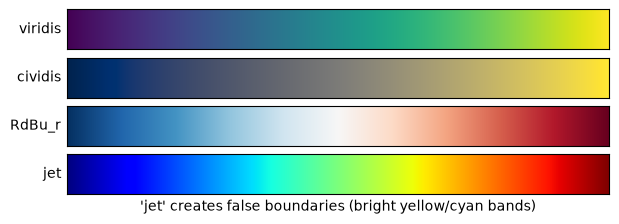

In [8]:
x = np.linspace(0, 1, 256)[None, :]
fig, axes = plt.subplots(4, 1, figsize=(7, 2.4))
for ax, cm in zip(axes, ["viridis", "cividis", "RdBu_r", "jet"]):
    ax.imshow(x, aspect="auto", cmap=cm); ax.set_yticks([]); ax.set_xticks([]); ax.set_ylabel(cm, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("'jet' creates false boundaries (bright yellow/cyan bands)")
plt.show()

## **Practice Problems**
1. Plot a histogram of `proline` for each cultivar in separate panels (3 subplots, shared x-axis).
2. Make a scatter plot of `alcohol` vs `color_intensity` with marker size proportional to `proline`.
3. Recreate the learning curve plot and mark the epoch with minimum validation loss with a vertical dashed line.

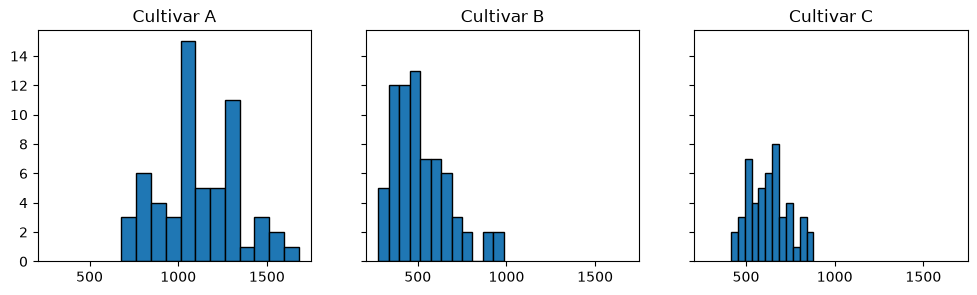

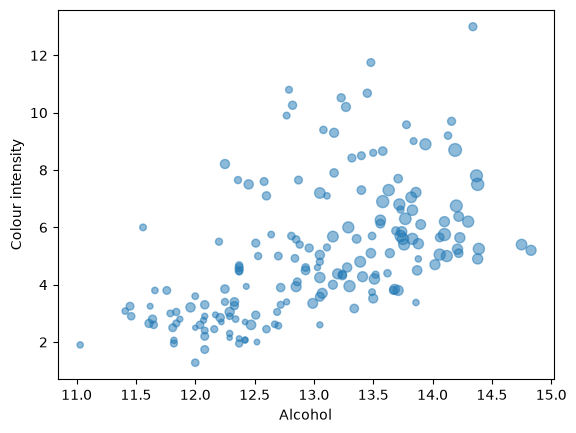

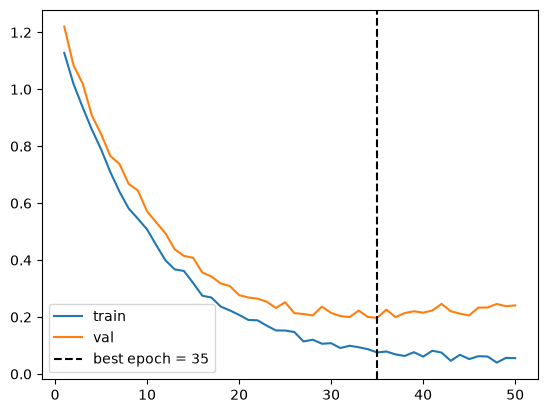

In [9]:
# Solution 1
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=True)
for ax, (c, g) in zip(axes, df.groupby("cultivar")):
    ax.hist(g.proline, bins=12, edgecolor="k"); ax.set_title(f"Cultivar {c}")
plt.show()
# Solution 2
plt.scatter(df.alcohol, df.color_intensity, s=df.proline / 20, alpha=0.5)
plt.xlabel("Alcohol"); plt.ylabel("Colour intensity"); plt.show()
# Solution 3
best = epochs[np.argmin(val_loss)]
plt.plot(epochs, train_loss, label="train"); plt.plot(epochs, val_loss, label="val")
plt.axvline(best, ls="--", c="k", label=f"best epoch = {best}"); plt.legend(); plt.show()

## **Key References**
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90-95.
- Waskom, M. L. (2021). seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.
- Rougier, N. P., Droettboom, M., & Bourne, P. E. (2014). Ten simple rules for better figures. *PLOS Computational Biology*, 10(9), e1003833.
- Crameri, F., Shephard, G. E., & Heron, P. J. (2020). The misuse of colour in science communication. *Nature Communications*, 11, 5444.